# Interactive Test Runner for test_thin.py

This notebook allows you to run individual tests from `fronts/tests/test_thin.py` interactively.

Each test can be run independently, and you can inspect results, visualize data, or debug as needed.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sys
from pathlib import Path

# Add parent directory to path if needed
sys.path.insert(0, str(Path.cwd().parent))

from fronts.finding.thin_cc import (
    thin,
    thin_fronts,
    compute_gradient_magnitude,
    MIN_VALID_SST_K,
    MIN_GRADIENT_K,
)

## Visualization Helper Functions

In [2]:
def plot_test_results(sst, fronts_before, fronts_after, title="Test Results"):
    """Plot SST, fronts before thinning, and fronts after thinning."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # SST field
    im0 = axes[0].imshow(sst, cmap='RdYlBu_r')
    axes[0].set_title('SST Field (K)')
    axes[0].set_xlabel('Column')
    axes[0].set_ylabel('Row')
    plt.colorbar(im0, ax=axes[0])
    
    # Fronts before
    im1 = axes[1].imshow(fronts_before, cmap='gray_r')
    axes[1].set_title(f'Before Thinning ({np.sum(fronts_before > 0)} pixels)')
    axes[1].set_xlabel('Column')
    axes[1].set_ylabel('Row')
    plt.colorbar(im1, ax=axes[1])
    
    # Fronts after
    im2 = axes[2].imshow(fronts_after, cmap='gray_r')
    axes[2].set_title(f'After Thinning ({np.sum(fronts_after > 0)} pixels)')
    axes[2].set_xlabel('Column')
    axes[2].set_ylabel('Row')
    plt.colorbar(im2, ax=axes[2])
    
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    
def plot_gradient(sst, gradient, title="Gradient Magnitude"):
    """Plot SST field and its gradient magnitude."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    im0 = axes[0].imshow(sst, cmap='RdYlBu_r')
    axes[0].set_title('SST Field (K)')
    plt.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(gradient, cmap='viridis')
    axes[1].set_title('Gradient Magnitude (K/pixel)')
    plt.colorbar(im1, ax=axes[1])
    
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

---
## TestThin Class

Tests for the core `thin()` function.

### Test: Basic Vertical Front

✓ test_basic_vertical_front PASSED
  Before: 150 pixels, After: 50 pixels


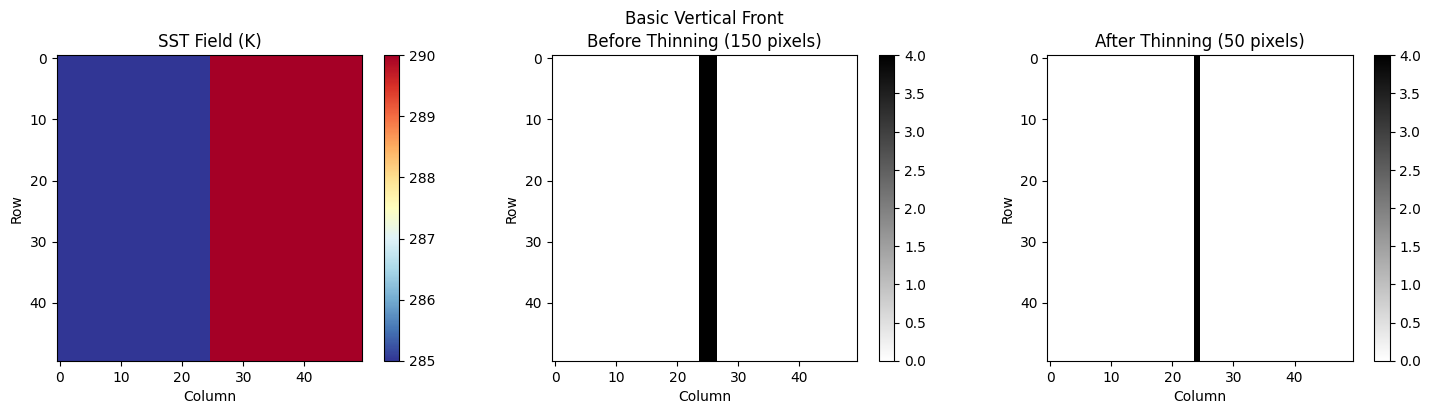

In [8]:
# Create SST field with horizontal gradient (cold left, warm right)
sst = np.full((50, 50), 285.0, dtype=np.float32)
sst[:, 25:] = 290.0  # 5K jump at column 25

# Create wide front band (3 pixels wide) at the gradient
fronts = np.zeros((50, 50), dtype=np.int16)
fronts[:, 24:27] = 4  # 3-pixel wide front

thinned = thin(sst, fronts)

# Assertions
assert np.sum(thinned == 4) < np.sum(fronts == 4), "Should thin to fewer pixels"
assert np.any(thinned[:, 24] == 4), "Should have fronts in the middle of the band"

print("✓ test_basic_vertical_front PASSED")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")
plot_test_results(sst, fronts, thinned, "Basic Vertical Front")

### Test: Basic Horizontal Front

✓ test_basic_horizontal_front PASSED
  Before: 150 pixels, After: 50 pixels


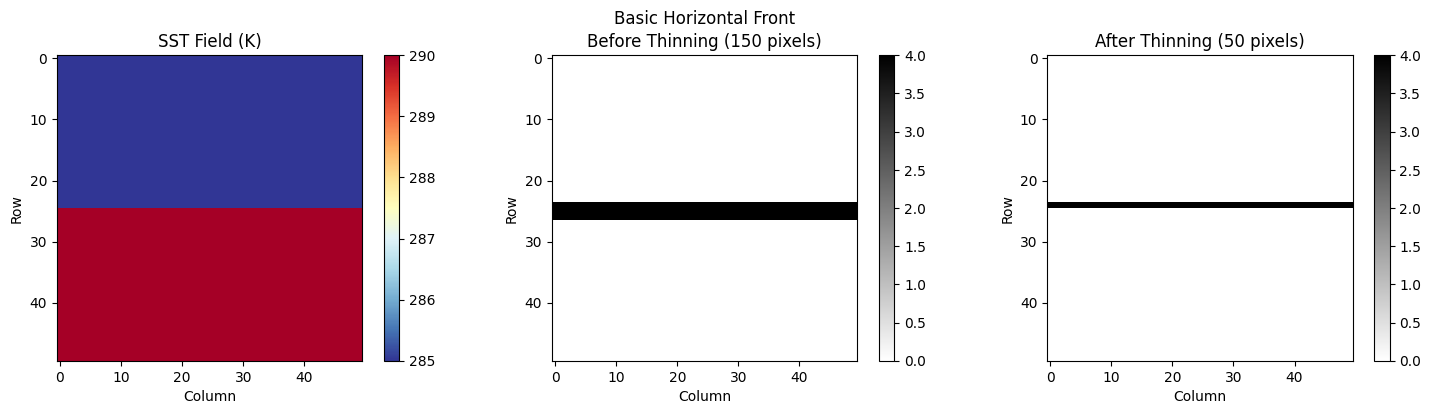

In [10]:
# Create SST field with vertical gradient (cold top, warm bottom)
sst = np.full((50, 50), 285.0, dtype=np.float32)
sst[25:, :] = 290.0  # 5K jump at row 25

# Create wide front band (3 pixels wide) at the gradient
fronts = np.zeros((50, 50), dtype=np.int16)
fronts[24:27, :] = 4  # 3-pixel wide front

thinned = thin(sst, fronts)

# Assertions
assert np.sum(thinned == 4) < np.sum(fronts == 4), "Should thin to fewer pixels"
assert np.any(thinned[24, :] == 4), "Should have fronts in the middle of the band"

print("✓ test_basic_horizontal_front PASSED")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")
plot_test_results(sst, fronts, thinned, "Basic Horizontal Front")

### Test: Diagonal Front

✓ test_diagonal_front PASSED
  Before: 234 pixels, After: 95 pixels


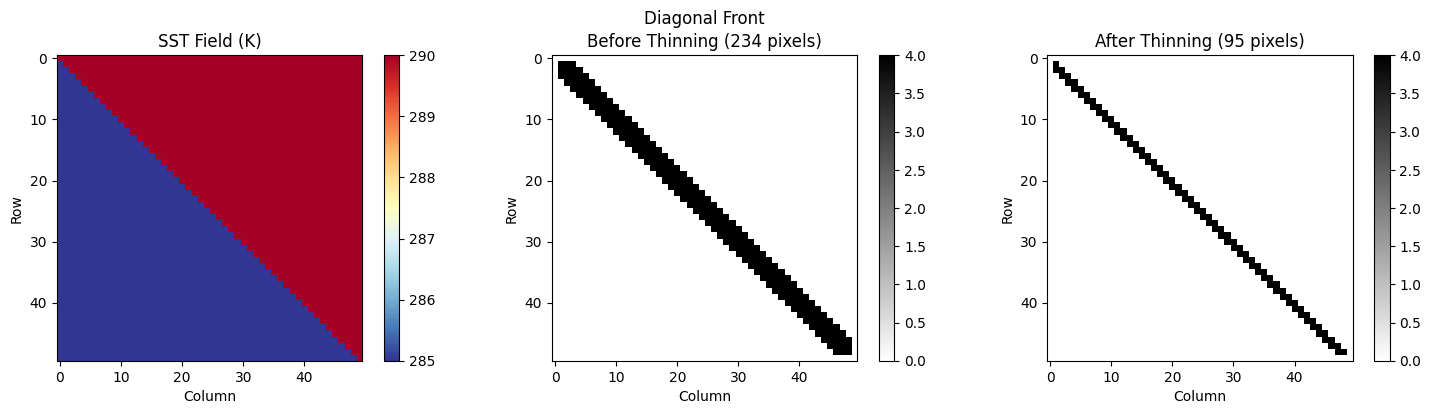

In [11]:
sst = np.full((50, 50), 285.0, dtype=np.float32)
# Create diagonal gradient
for i in range(50):
    sst[i, i:] = 290.0

# Create diagonal front band
fronts = np.zeros((50, 50), dtype=np.int16)
for i in range(2, 48):
    fronts[i-1:i+2, i-1:i+2] = 4

thinned = thin(sst, fronts)

# Assertions
assert np.sum(thinned == 4) < np.sum(fronts == 4), "Should reduce pixel count"
assert np.sum(thinned == 4) > 0, "Should still have some fronts"

print("✓ test_diagonal_front PASSED")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")
plot_test_results(sst, fronts, thinned, "Diagonal Front")

### Test: No Fronts Input

In [12]:
sst = np.full((50, 50), 290.0, dtype=np.float32)
fronts = np.zeros((50, 50), dtype=np.int16)

thinned = thin(sst, fronts)

assert np.sum(thinned == 4) == 0, "Should have no fronts"

print("✓ test_no_fronts_input PASSED")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")

✓ test_no_fronts_input PASSED
  Before: 0 pixels, After: 0 pixels


### Test: NaN Handling

✓ test_nan_handling PASSED
  Before: 150 pixels, After: 40 pixels


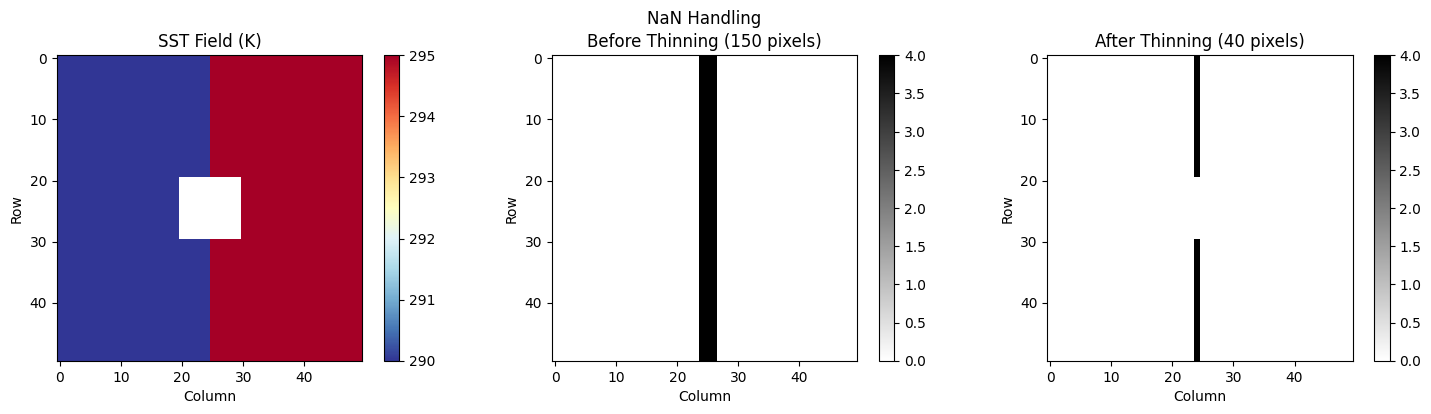

In [13]:
sst = np.full((50, 50), 290.0, dtype=np.float32)
sst[:, 25:] = 295.0
sst[20:30, 20:30] = np.nan  # NaN block in middle

fronts = np.zeros((50, 50), dtype=np.int16)
fronts[:, 24:27] = 4

thinned = thin(sst, fronts)

# Should not place fronts where SST is NaN
nan_mask = np.isnan(sst)
assert not np.any((thinned == 4) & nan_mask), "No fronts should be in NaN regions"

print("✓ test_nan_handling PASSED")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")
plot_test_results(sst, fronts, thinned, "NaN Handling")

### Test: Cold Pixels Excluded

✓ test_cold_pixels_excluded PASSED
  MIN_VALID_SST_K = 271.35 K
  Before: 150 pixels, After: 40 pixels


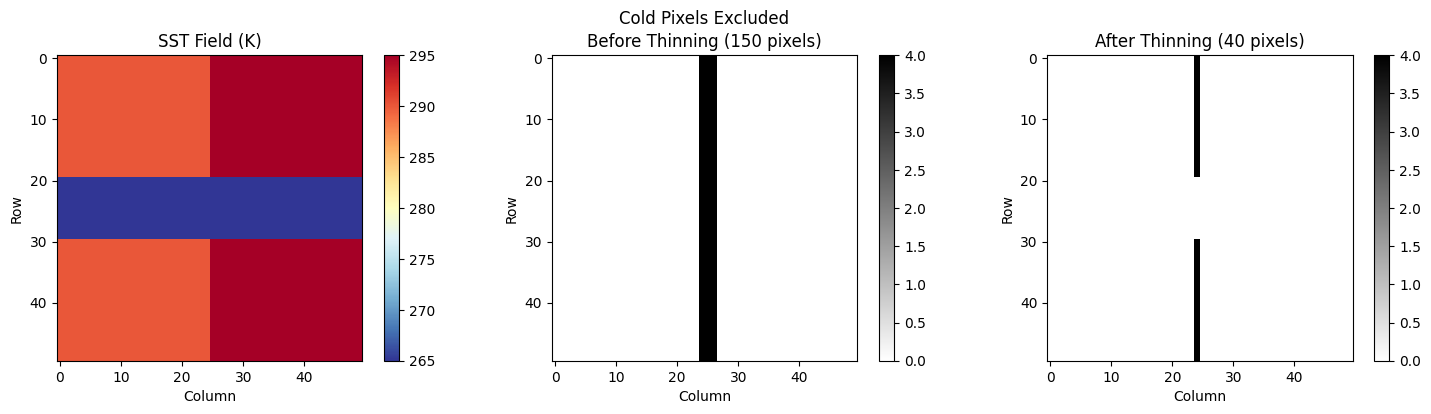

In [14]:
sst = np.full((50, 50), 290.0, dtype=np.float32)
sst[:, 25:] = 295.0
sst[20:30, :] = 265.0  # Below freezing - invalid

fronts = np.zeros((50, 50), dtype=np.int16)
fronts[:, 24:27] = 4

thinned = thin(sst, fronts)

cold_mask = sst < MIN_VALID_SST_K
assert np.sum(thinned == 4) > 0, "Should have some fronts"

print("✓ test_cold_pixels_excluded PASSED")
print(f"  MIN_VALID_SST_K = {MIN_VALID_SST_K} K")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")
plot_test_results(sst, fronts, thinned, "Cold Pixels Excluded")

### Test: Shape Mismatch Raises

In [15]:
sst = np.full((50, 50), 290.0, dtype=np.float32)
fronts = np.zeros((60, 60), dtype=np.int16)

try:
    thin(sst, fronts)
    print("✗ test_shape_mismatch_raises FAILED - No exception raised")
except ValueError as e:
    if "Shape mismatch" in str(e):
        print("✓ test_shape_mismatch_raises PASSED")
        print(f"  Caught expected exception: {e}")
    else:
        print(f"✗ test_shape_mismatch_raises FAILED - Wrong error message: {e}")

✓ test_shape_mismatch_raises PASSED
  Caught expected exception: Shape mismatch: med_sst (50, 50) vs merged_fronts (60, 60)


### Test: Custom Front Value

✓ test_custom_front_value PASSED
  Before: 150 pixels, After: 50 pixels


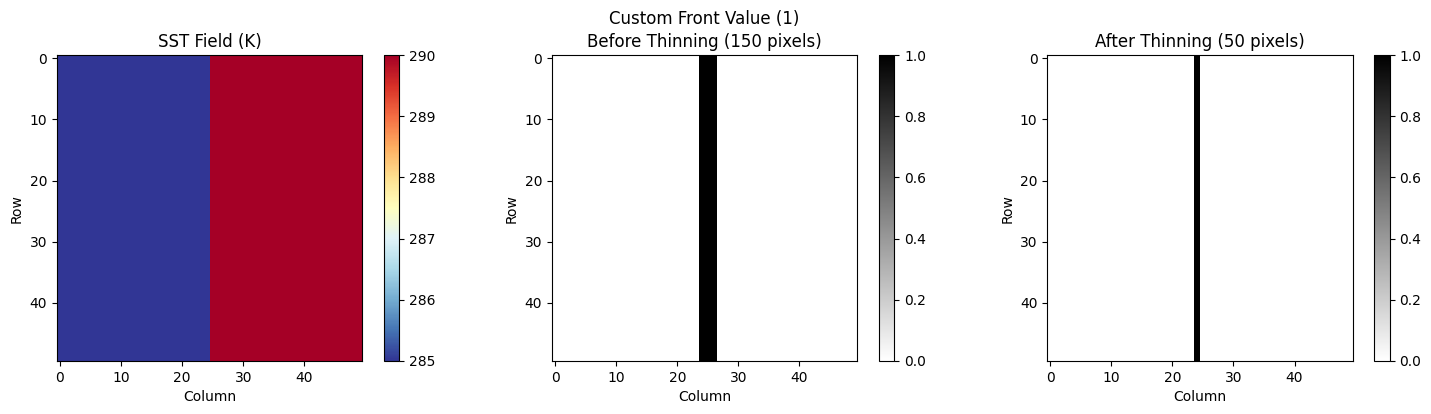

In [16]:
sst = np.full((50, 50), 285.0, dtype=np.float32)
sst[:, 25:] = 290.0

fronts = np.zeros((50, 50), dtype=np.int16)
fronts[:, 24:27] = 1  # Use 1 instead of 4

thinned = thin(sst, fronts, front_value=1)

assert np.any(thinned == 1), "Should have fronts with value 1"
assert not np.any(thinned == 4), "Should not have fronts with value 4"

print("✓ test_custom_front_value PASSED")
print(f"  Before: {np.sum(fronts == 1)} pixels, After: {np.sum(thinned == 1)} pixels")
plot_test_results(sst, fronts, thinned, "Custom Front Value (1)")

### Test: Custom Min Gradient

✓ test_custom_min_gradient PASSED
  Default threshold: 0 pixels
  Lower threshold (0.005): 50 pixels


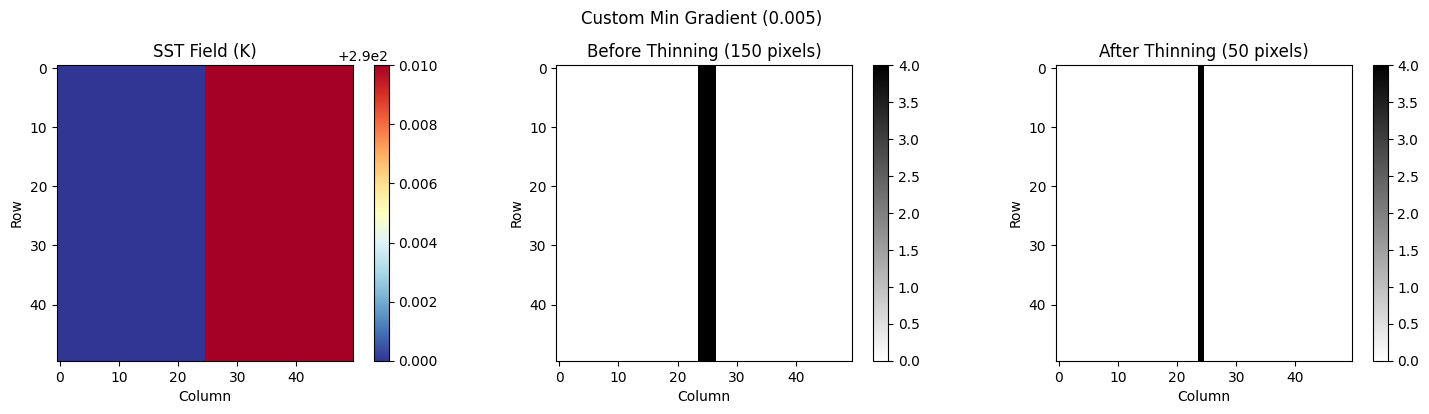

In [17]:
sst = np.full((50, 50), 290.0, dtype=np.float32)
sst[:, 25:] = 290.01  # Very small gradient (0.01 K)

fronts = np.zeros((50, 50), dtype=np.int16)
fronts[:, 24:27] = 4

# With default min_gradient (0.02), should find no/few fronts
thinned_default = thin(sst, fronts)

# With lower threshold, should find fronts
thinned_low = thin(sst, fronts, min_gradient=0.005)

assert np.sum(thinned_default == 4) <= np.sum(thinned_low == 4), "Lower threshold should find more fronts"

print("✓ test_custom_min_gradient PASSED")
print(f"  Default threshold: {np.sum(thinned_default == 4)} pixels")
print(f"  Lower threshold (0.005): {np.sum(thinned_low == 4)} pixels")
plot_test_results(sst, fronts, thinned_low, "Custom Min Gradient (0.005)")

### Test: Realistic Temperature Range

✓ test_realistic_temperature_range PASSED
  Before: 500 pixels, After: 103 pixels


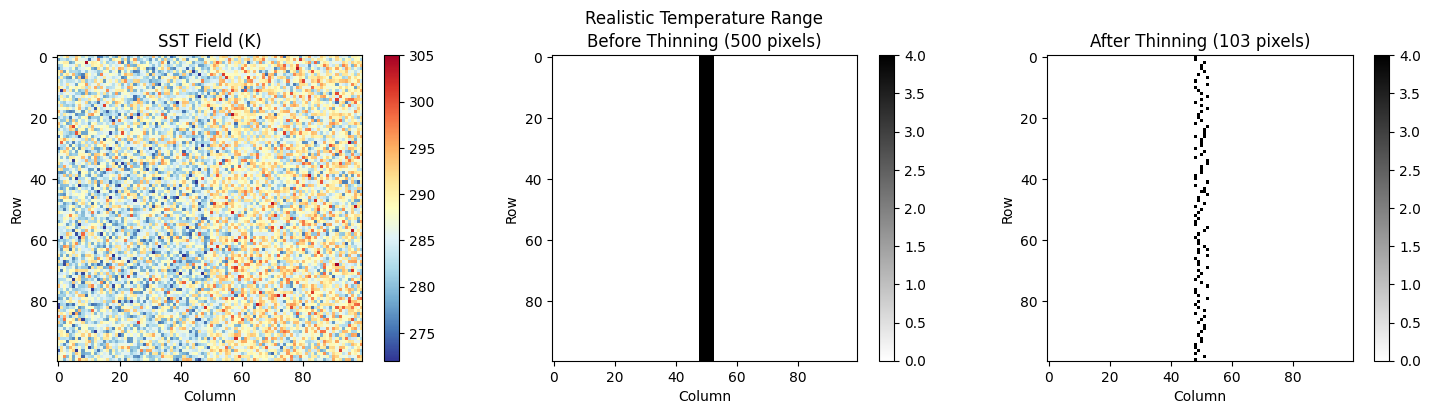

In [18]:
# Create realistic SST field
np.random.seed(42)
sst = 285.0 + 5.0 * np.random.randn(100, 100)
sst = np.clip(sst, 272, 305).astype(np.float32)

# Add a clear front
sst[:, 50:] += 3.0
sst = np.clip(sst, 272, 305)

fronts = np.zeros((100, 100), dtype=np.int16)
fronts[:, 48:53] = 4

thinned = thin(sst, fronts)

# Should reduce but not eliminate
original_count = np.sum(fronts == 4)
thinned_count = np.sum(thinned == 4)
assert 0 < thinned_count < original_count, "Should reduce but not eliminate fronts"

print("✓ test_realistic_temperature_range PASSED")
print(f"  Before: {original_count} pixels, After: {thinned_count} pixels")
plot_test_results(sst, fronts, thinned, "Realistic Temperature Range")

### Test: Multiple Separate Fronts

✓ test_multiple_separate_fronts PASSED
  Before: 1000 pixels, After: 200 pixels


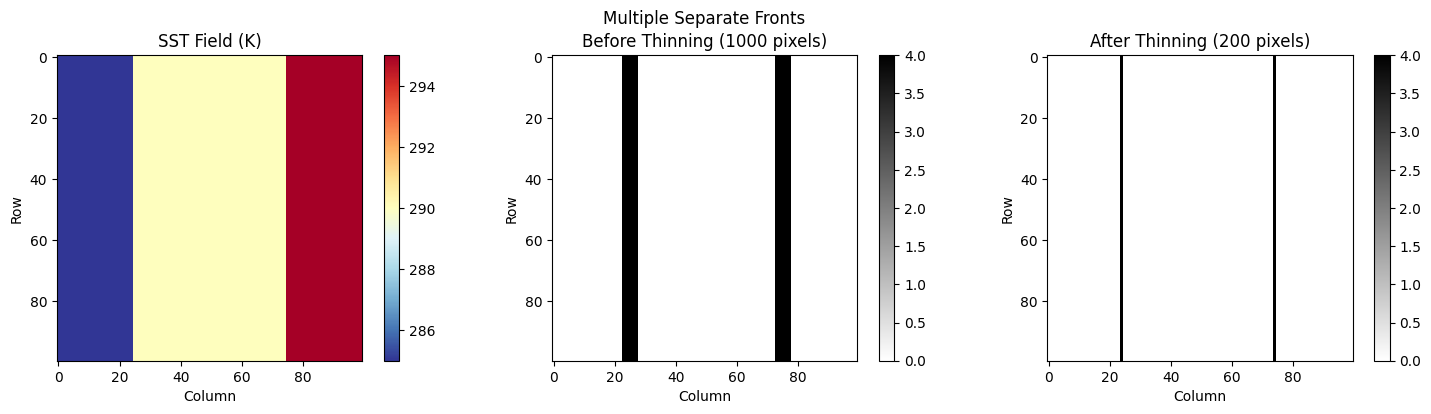

In [19]:
sst = np.full((100, 100), 285.0, dtype=np.float32)
sst[:, 25:] = 290.0
sst[:, 75:] = 295.0

fronts = np.zeros((100, 100), dtype=np.int16)
fronts[:, 23:28] = 4  # First front
fronts[:, 73:78] = 4  # Second front

thinned = thin(sst, fronts)

# Should have fronts at both locations
assert np.any(thinned[:, 23:28] == 4), "Should have fronts at first location"
assert np.any(thinned[:, 73:78] == 4), "Should have fronts at second location"

print("✓ test_multiple_separate_fronts PASSED")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")
plot_test_results(sst, fronts, thinned, "Multiple Separate Fronts")

---
## TestThinFronts Class

Tests for the `thin_fronts()` convenience wrapper.

### Test: With Median Filter

✓ test_with_median_filter PASSED
  Before: 150 pixels, After: 52 pixels


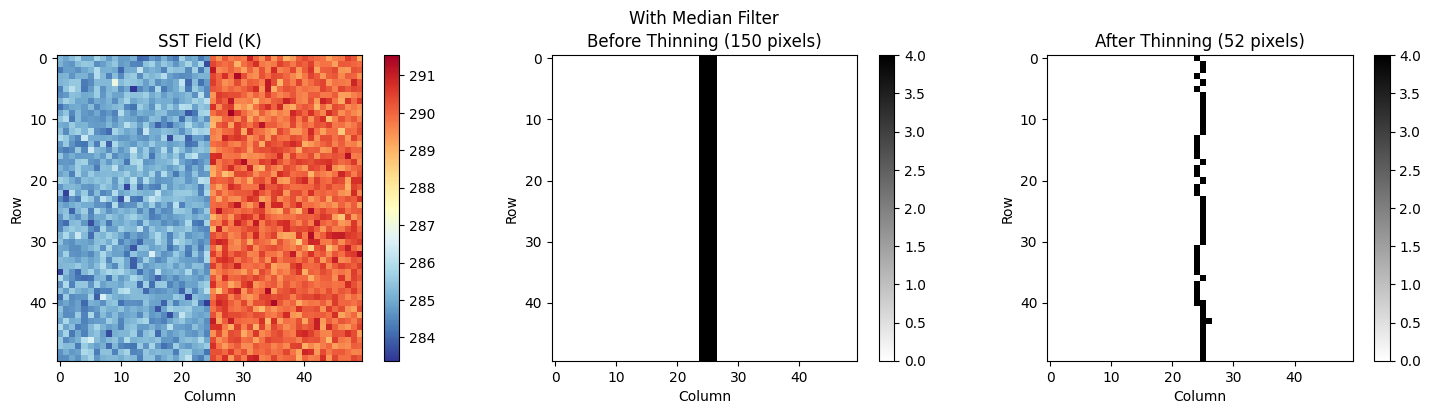

In [20]:
# Create noisy SST
np.random.seed(42)
sst = np.full((50, 50), 285.0, dtype=np.float32)
sst[:, 25:] = 290.0
sst += 0.5 * np.random.randn(50, 50).astype(np.float32)

fronts = np.zeros((50, 50), dtype=np.int16)
fronts[:, 24:27] = 4

thinned = thin_fronts(sst, fronts, apply_median=True, median_size=5)

assert np.sum(thinned == 4) > 0, "Should have some fronts"
assert np.sum(thinned == 4) < np.sum(fronts == 4), "Should thin"

print("✓ test_with_median_filter PASSED")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")
plot_test_results(sst, fronts, thinned, "With Median Filter")

### Test: Without Median Filter

✓ test_without_median_filter PASSED
  Before: 150 pixels, After: 50 pixels


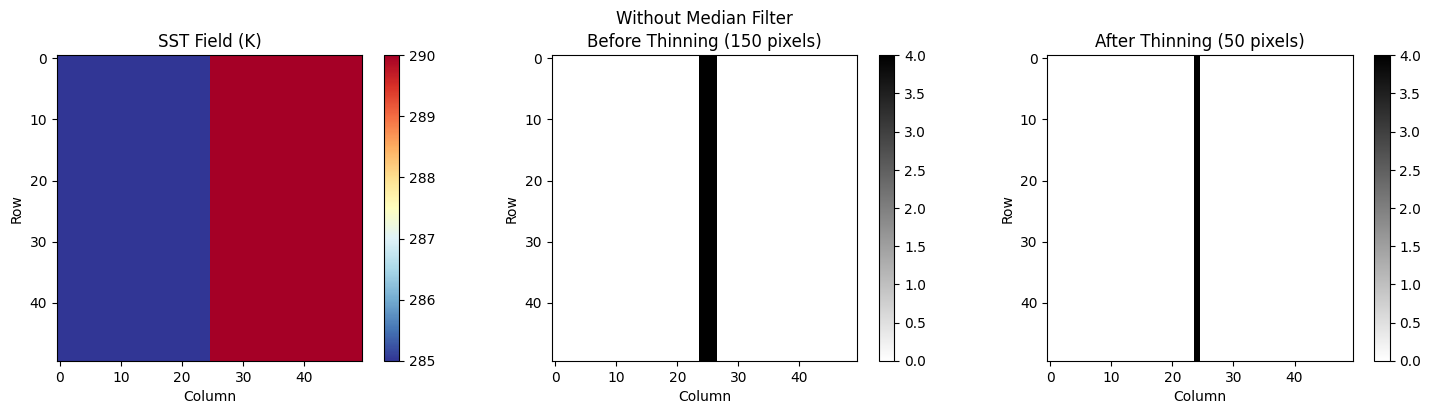

In [21]:
sst = np.full((50, 50), 285.0, dtype=np.float32)
sst[:, 25:] = 290.0

fronts = np.zeros((50, 50), dtype=np.int16)
fronts[:, 24:27] = 4

thinned = thin_fronts(sst, fronts, apply_median=False)

assert np.sum(thinned == 4) > 0, "Should have some fronts"

print("✓ test_without_median_filter PASSED")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")
plot_test_results(sst, fronts, thinned, "Without Median Filter")

### Test: NaN Preserved After Median

✓ test_nan_preserved_after_median PASSED
  Before: 150 pixels, After: 44 pixels


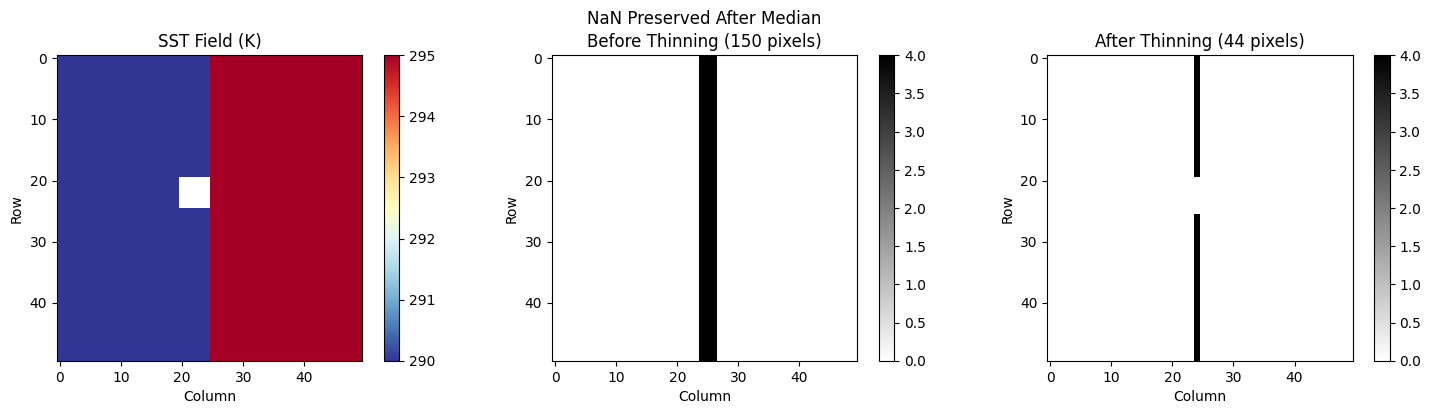

In [22]:
sst = np.full((50, 50), 290.0, dtype=np.float32)
sst[:, 25:] = 295.0
sst[20:25, 20:25] = np.nan

fronts = np.zeros((50, 50), dtype=np.int16)
fronts[:, 24:27] = 4

thinned = thin_fronts(sst, fronts, apply_median=True)

# NaN region should not have fronts
nan_mask = np.isnan(sst)
assert not np.any((thinned == 4) & nan_mask), "No fronts in NaN region"

print("✓ test_nan_preserved_after_median PASSED")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")
plot_test_results(sst, fronts, thinned, "NaN Preserved After Median")

---
## TestComputeGradientMagnitude Class

Tests for `compute_gradient_magnitude()`.

### Test: Uniform Field

✓ test_uniform_field PASSED
  Max gradient in interior: 0.000000 K/pixel


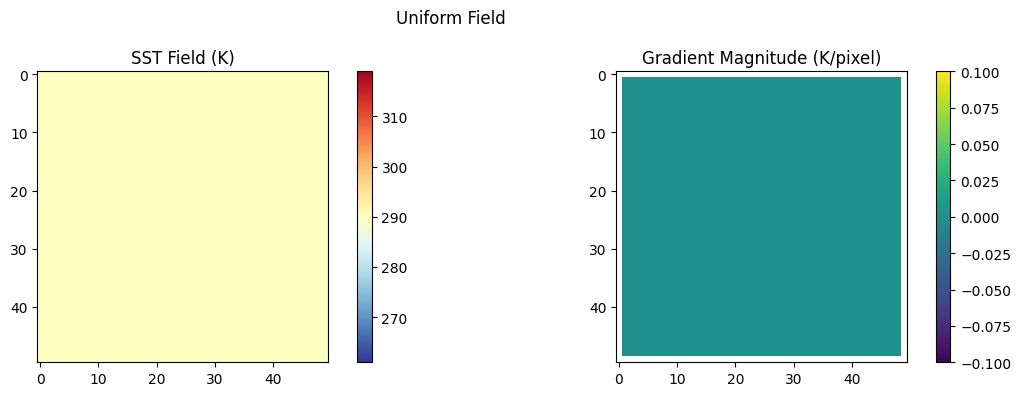

In [23]:
sst = np.full((50, 50), 290.0, dtype=np.float32)
gradient = compute_gradient_magnitude(sst)

# Interior should be ~0 (excluding boundaries which are NaN)
interior = gradient[2:-2, 2:-2]
assert np.allclose(interior, 0, atol=1e-6), "Uniform field should have zero gradient"

print("✓ test_uniform_field PASSED")
print(f"  Max gradient in interior: {np.nanmax(interior):.6f} K/pixel")
plot_gradient(sst, gradient, "Uniform Field")

### Test: Horizontal Gradient

✓ test_horizontal_gradient PASSED
  Mean gradient: 1.000 K/pixel


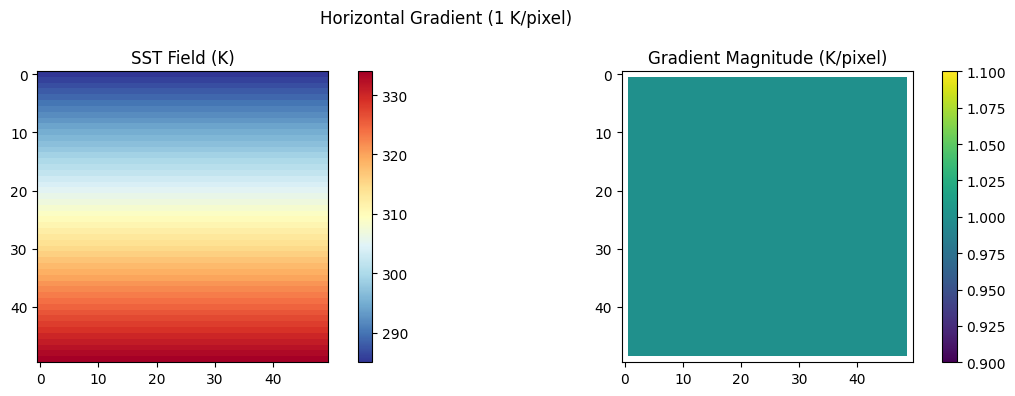

In [24]:
sst = np.zeros((50, 50), dtype=np.float32) + 285.0
# Linear gradient in x: 1 K per pixel
for i in range(50):
    sst[i, :] = 285.0 + i * 1.0

gradient = compute_gradient_magnitude(sst)

# Should have gradient ~1 K/pixel in interior
interior = gradient[2:-2, 2:-2]
valid = ~np.isnan(interior)
assert np.allclose(interior[valid], 1.0, atol=0.1), "Should have ~1 K/pixel gradient"

print("✓ test_horizontal_gradient PASSED")
print(f"  Mean gradient: {np.nanmean(interior):.3f} K/pixel")
plot_gradient(sst, gradient, "Horizontal Gradient (1 K/pixel)")

### Test: Vertical Gradient

✓ test_vertical_gradient PASSED
  Mean gradient: 1.000 K/pixel


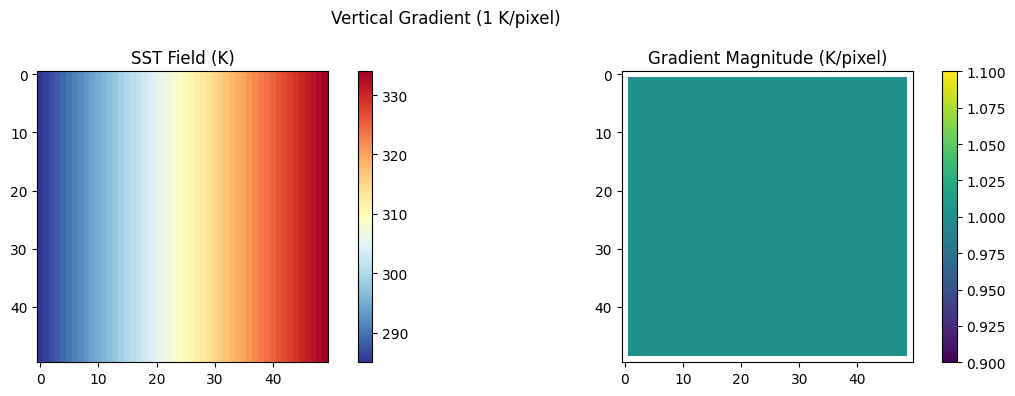

In [25]:
sst = np.zeros((50, 50), dtype=np.float32) + 285.0
# Linear gradient in y: 1 K per pixel
for j in range(50):
    sst[:, j] = 285.0 + j * 1.0

gradient = compute_gradient_magnitude(sst)

# Should have gradient ~1 K/pixel in interior
interior = gradient[2:-2, 2:-2]
valid = ~np.isnan(interior)
assert np.allclose(interior[valid], 1.0, atol=0.1), "Should have ~1 K/pixel gradient"

print("✓ test_vertical_gradient PASSED")
print(f"  Mean gradient: {np.nanmean(interior):.3f} K/pixel")
plot_gradient(sst, gradient, "Vertical Gradient (1 K/pixel)")

### Test: NaN Handling in Gradient

✓ test_nan_handling PASSED
  NaN pixels in gradient: 201


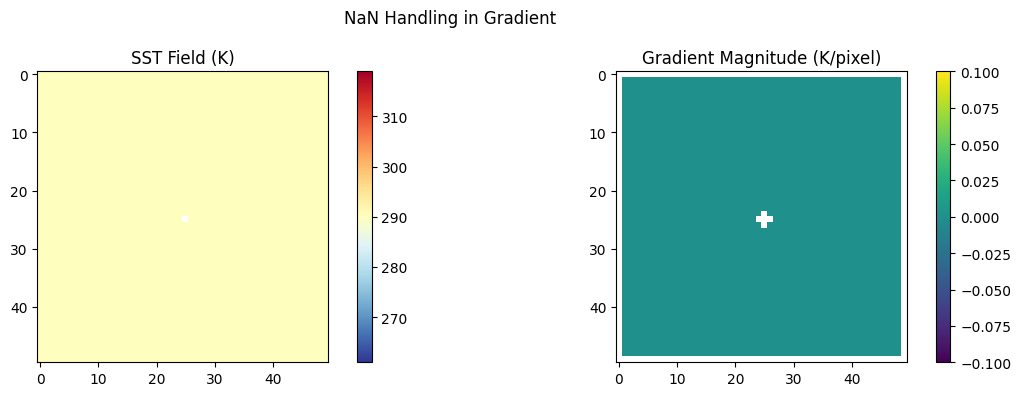

In [26]:
sst = np.full((50, 50), 290.0, dtype=np.float32)
sst[25, 25] = np.nan

gradient = compute_gradient_magnitude(sst)

# The NaN pixel and its neighbors should be NaN in gradient
assert np.isnan(gradient[25, 25]), "NaN pixel should have NaN gradient"
assert np.isnan(gradient[24, 25]), "Neighbor should have NaN gradient"
assert np.isnan(gradient[26, 25]), "Neighbor should have NaN gradient"
assert np.isnan(gradient[25, 24]), "Neighbor should have NaN gradient"
assert np.isnan(gradient[25, 26]), "Neighbor should have NaN gradient"

print("✓ test_nan_handling PASSED")
print(f"  NaN pixels in gradient: {np.sum(np.isnan(gradient))}")
plot_gradient(sst, gradient, "NaN Handling in Gradient")

### Test: Cold Pixels Excluded from Gradient

✓ test_cold_pixels_excluded PASSED
  MIN_VALID_SST_K = 271.35 K


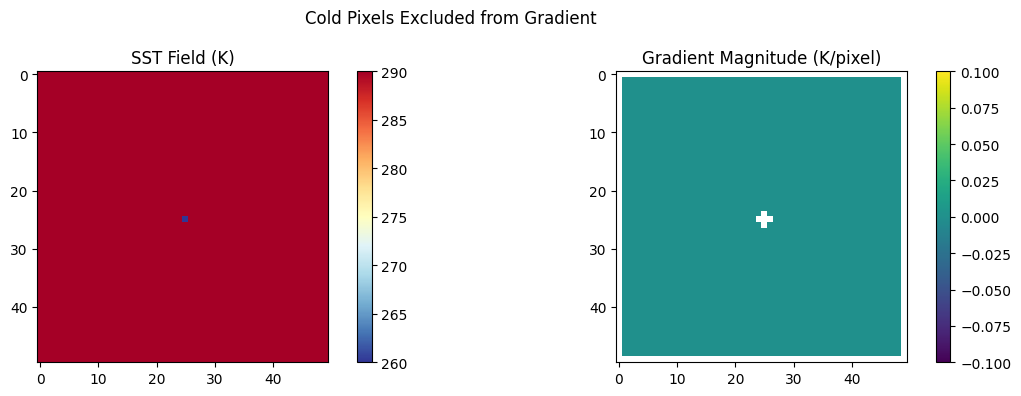

In [27]:
sst = np.full((50, 50), 290.0, dtype=np.float32)
sst[25, 25] = 260.0  # Below min valid

gradient = compute_gradient_magnitude(sst)

# The cold pixel should have NaN gradient
assert np.isnan(gradient[25, 25]), "Cold pixel should have NaN gradient"

print("✓ test_cold_pixels_excluded PASSED")
print(f"  MIN_VALID_SST_K = {MIN_VALID_SST_K} K")
plot_gradient(sst, gradient, "Cold Pixels Excluded from Gradient")

---
## TestEdgeCases Class

Tests for edge cases and boundary conditions.

### Test: Small Array

In [28]:
sst = np.array([[285, 290, 285],
                [285, 290, 285],
                [285, 290, 285]], dtype=np.float32)
fronts = np.array([[0, 4, 0],
                  [0, 4, 0],
                  [0, 4, 0]], dtype=np.int16)

thinned = thin(sst, fronts)

# Should work without error
assert thinned.shape == (3, 3), "Should preserve shape"

print("✓ test_small_array PASSED")
print(f"  Shape: {thinned.shape}")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")

✓ test_small_array PASSED
  Shape: (3, 3)
  Before: 3 pixels, After: 0 pixels


### Test: Single Front Pixel

✓ test_single_front_pixel PASSED
  Before: 1 pixels, After: 1 pixels


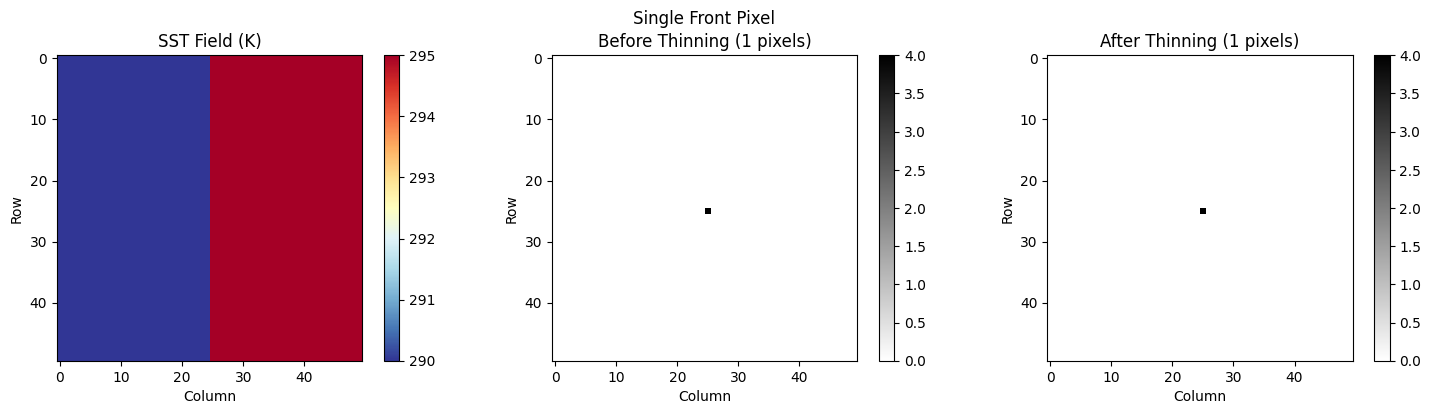

In [29]:
sst = np.full((50, 50), 290.0, dtype=np.float32)
sst[:, 25:] = 295.0

fronts = np.zeros((50, 50), dtype=np.int16)
fronts[25, 25] = 4  # Single pixel

thinned = thin(sst, fronts)

# Single pixel should be preserved or removed based on gradient
assert np.sum(thinned == 4) <= 1, "Should have at most one front pixel"

print("✓ test_single_front_pixel PASSED")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")
plot_test_results(sst, fronts, thinned, "Single Front Pixel")

### Test: All Fronts

✓ test_all_fronts PASSED
  Before: 400 pixels, After: 20 pixels


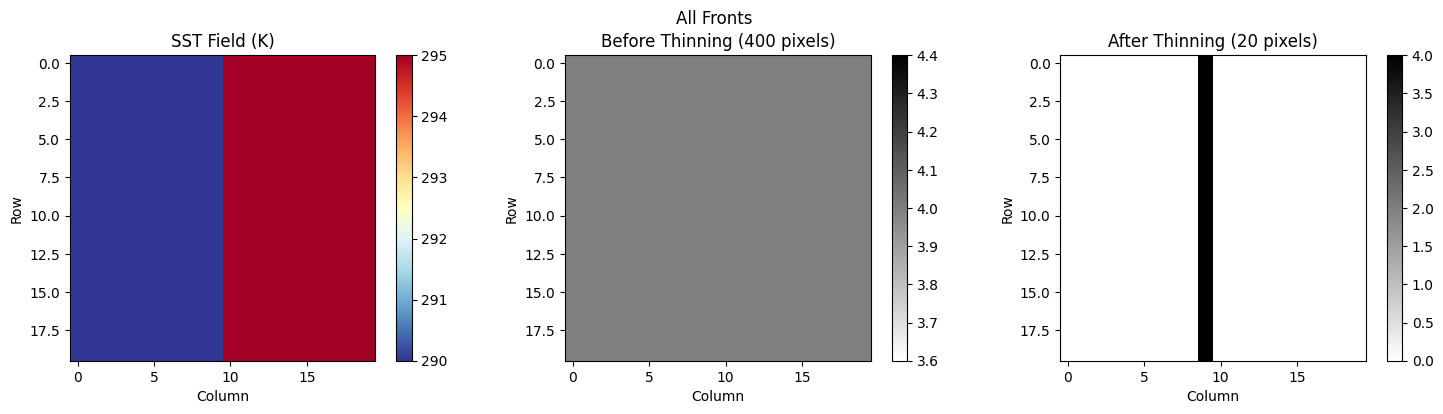

In [30]:
sst = np.full((20, 20), 290.0, dtype=np.float32)
sst[:, 10:] = 295.0

fronts = np.full((20, 20), 4, dtype=np.int16)

thinned = thin(sst, fronts)

# Should still thin
assert np.sum(thinned == 4) < np.sum(fronts == 4), "Should thin even when all pixels are fronts"

print("✓ test_all_fronts PASSED")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")
plot_test_results(sst, fronts, thinned, "All Fronts")

### Test: Boundary Fronts

✓ test_boundary_fronts PASSED
  Before: 196 pixels, After: 2 pixels


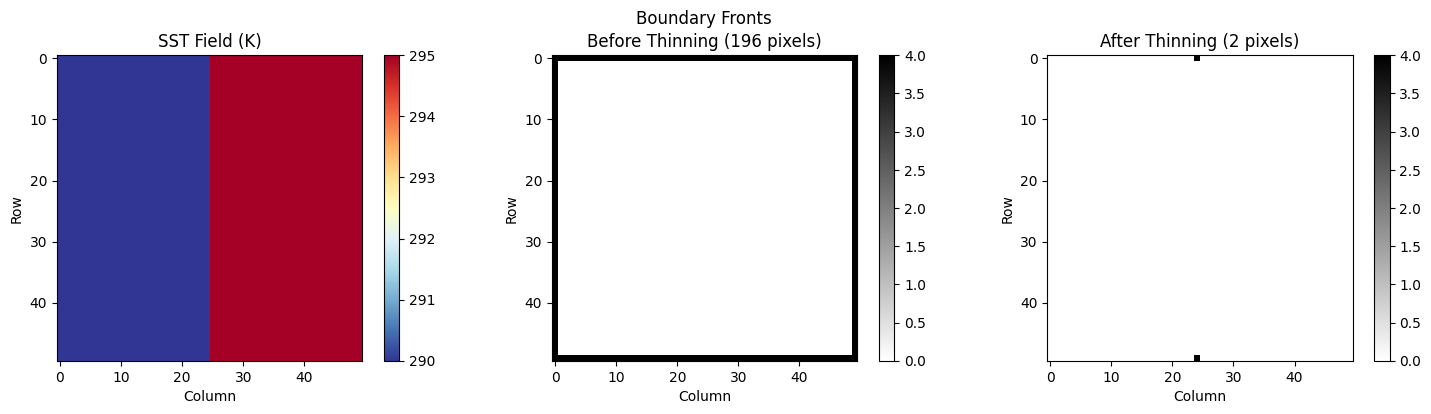

In [31]:
sst = np.full((50, 50), 290.0, dtype=np.float32)
sst[:, 25:] = 295.0

fronts = np.zeros((50, 50), dtype=np.int16)
fronts[0, :] = 4  # Top edge
fronts[-1, :] = 4  # Bottom edge
fronts[:, 0] = 4  # Left edge
fronts[:, -1] = 4  # Right edge

# Should not crash on boundary pixels
thinned = thin(sst, fronts)
assert thinned.shape == fronts.shape, "Should preserve shape"

print("✓ test_boundary_fronts PASSED")
print(f"  Before: {np.sum(fronts == 4)} pixels, After: {np.sum(thinned == 4)} pixels")
plot_test_results(sst, fronts, thinned, "Boundary Fronts")

---
## Run All Tests

Execute this cell to run all tests sequentially.

In [32]:
print("Running all tests from test_thin.py...\n")

test_count = 0
passed_count = 0

# Note: This is a simplified runner - the actual test cells above have more detailed output
print("\nTo run tests individually, execute the cells above.")
print("\nAlternatively, run: pytest fronts/tests/test_thin.py")

Running all tests from test_thin.py...


To run tests individually, execute the cells above.

Alternatively, run: pytest fronts/tests/test_thin.py
